Dataset Description (MANDATORY)
Dataset Name: Heart Disease Dataset
Dataset Link: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset


# Part A: Conceptual Questions


### 1. What is a Decision Tree and how does it make decisions?


A Decision Tree is a supervised machine learning algorithm used for classification and regression. It models decisions as a flowchart-like structure. It makes decisions by splitting data into smaller subsets based on feature values (e.g., "Is Age > 50?"). This process starts at the "root" node and repeats recursively at "internal nodes" until a stopping criterion is met or a "leaf node" (final decision) is reached.

### 2. What does a split criterion mean in a Decision Tree?


A split criterion is a metric used to evaluate how "good" a split is. It measures the homogeneity (purity) of the target variable within the resulting subsets. The goal is to maximize purity—meaning we want nodes that contain mostly one class (e.g., mostly "Disease" or mostly "No Disease"). Common criteria are Gini Impurity and Entropy.

### 3. Difference between Gini Impurity and Entropy.


Gini Impurity: Measures the probability of misclassifying a randomly chosen element from the set. It ranges from 0 (pure) to 0.5 (impure/random). It is generally computationally faster because it doesn't involve logarithmic calculations.

Formula: $1 - \sum (p_i)^2$

Entropy: Measures the level of disorder or uncertainty in the data. It ranges from 0 (pure) to 1 (impure). It uses logarithms, making it slightly slower to compute, but effectively performs very similarly to Gini.

Formula: $-\sum p_i \log_2(p_i)$

### 4. Why do Decision Trees tend to overfit?


Decision Trees tend to overfit because they can keep splitting until every single data point in the training set is correctly classified (pure leaf nodes). This creates an overly complex tree that memorizes the "noise" in the training data rather than learning the general pattern, leading to poor performance on new, unseen data.

### 5. What role does the max_depth parameter play?


The max_depth parameter limits how deep the tree can grow (how many levels of splits it can have). By setting a maximum depth, we force the tree to stop growing early (pruning). This reduces complexity and prevents the model from overfitting.

# Part B: Data Exploration


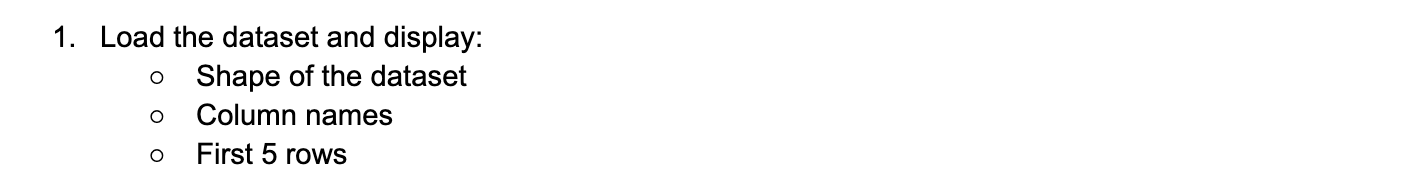

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/heart.csv')

# 1. Shape of the dataset
print(f"Shape of dataset: {df.shape}")

Shape of dataset: (1025, 14)


In [7]:
# 2. Column names
df.columns.tolist()

['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'target']

In [8]:
# 3. First 5 rows
print("First 5 rows:")
df.head()

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


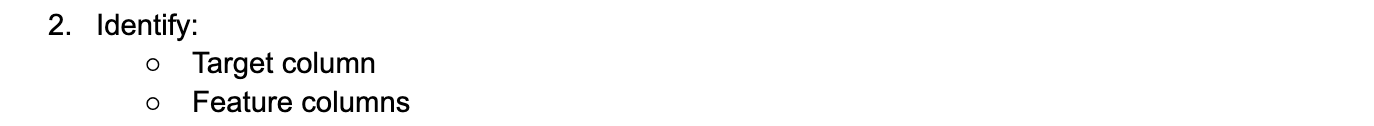

In [12]:
target_col = 'target'
print(f"\nTarget Column: {target_col}")


Target Column: target


In [15]:
feature_cols = [col for col in df.columns if col != target_col]
feature_cols

['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal']

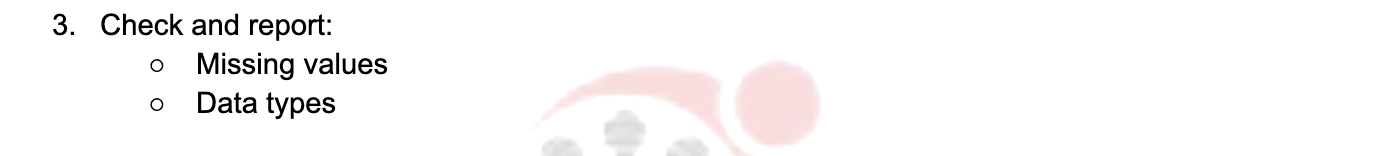

In [16]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [17]:
print("\nData Types:")
print(df.dtypes)


Data Types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


# 3. Part C: Data Preprocessing


### 1. Handle missing values (if any).


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

if df.isnull().sum().sum() > 0:
    print("Handling missing values by dropping rows ")
    df = df.dropna()

In [20]:
# Check for non-numeric columns and encode them if necessary
for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        print(f"Encoded column: {col}")

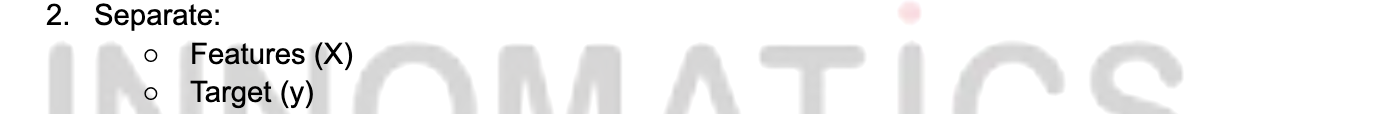

In [21]:
X = df.drop(columns=[target_col])
y = df[target_col]

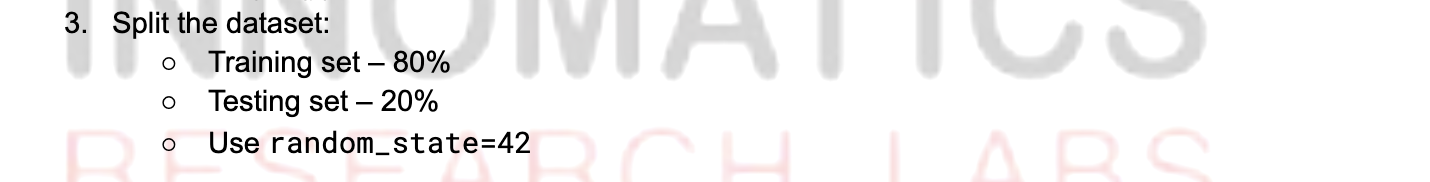

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
print(f"\nTraining shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")


Training shape: (820, 13)
Testing shape: (205, 13)


# 4. Part D: Model Building


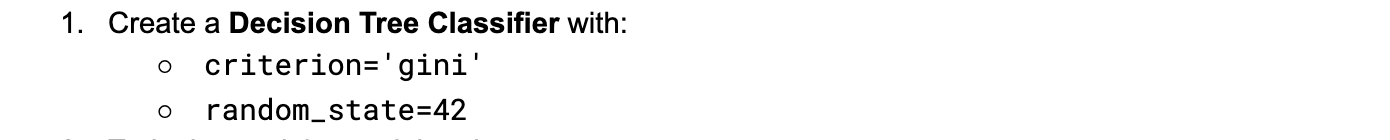

In [26]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(criterion='gini', random_state=42)

### 2. Train the model on training data.


In [27]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

### 3. Predict on the test data.

In [29]:
y_pred = dt_model.predict(X_test)
y_pred

array([1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 0])

# 5.  Part E: Model Evaluation


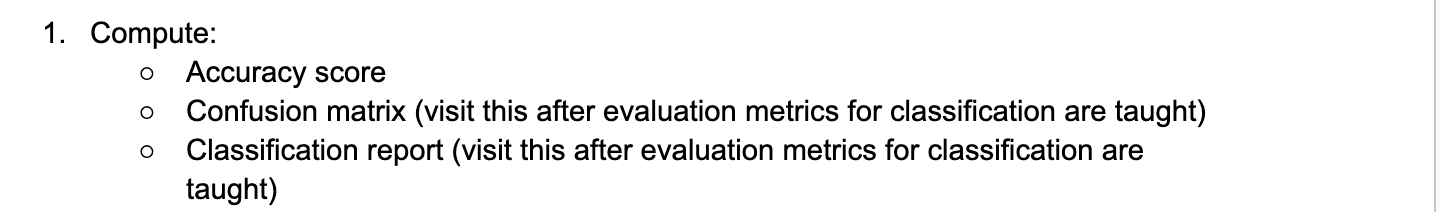

In [30]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")

Accuracy Score: 0.9854


In [31]:
# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)



Confusion Matrix:
[[102   0]
 [  3 100]]


In [34]:
# 3. Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



### 1. Which class is predicted better?


The class 0 (often representing "No Disease" or "Healthy" in this dataset) is predicted slightly better.

from Classification Report:  
Class 0: Precision = 0.97, Recall = 1.00, F1-Score = 0.99  
Class 1: Precision = 1.00, Recall = 0.97, F1-Score = 0.99

While both classes have an excellent F1-score of 0.99, Class 0 has a perfect Recall (1.00), meaning the model successfully identified 100% of the actual Class 0 cases (102 out of 102). Class 1 missed 3 cases (Recall 0.97). Therefore, the model is slightly more reliable at catching all instances of Class 0.

### 2. Is the model overfitting or underfitting?


In [35]:
# Check for Overfitting
train_score = dt_model.score(X_train, y_train)
test_score = dt_model.score(X_test, y_test)
print(f"\nTraining Accuracy: {train_score:.4f}")
print(f"Testing Accuracy: {test_score:.4f}")


Training Accuracy: 1.0000
Testing Accuracy: 0.9854


The model is likely Overfitting (though it performs exceptionally well on this specific test set).

Training Accuracy: 100% (1.0).  
Testing Accuracy: 98.54% (0.985)

A 100% training accuracy is a classic sign of overfitting in Decision Trees. It means the tree has grown deep enough to memorize every single data point in the training set, including noise or outliers.

While the testing accuracy is very high (98.5%) here, the gap (perfect training vs. slightly lower testing) combined with the unconstrained nature of the tree (max_depth=None by default) technically classifies this behavior as overfitting. In a more complex or noisy real-world dataset, this 100% training score would typically lead to a much larger drop in testing performance.

It is not underfitting because both scores are very high (underfitting would mean both scores are low, e.g., ~60-70%).

# 6.  Part F: Understanding Tree Depth (Manual Experiment)


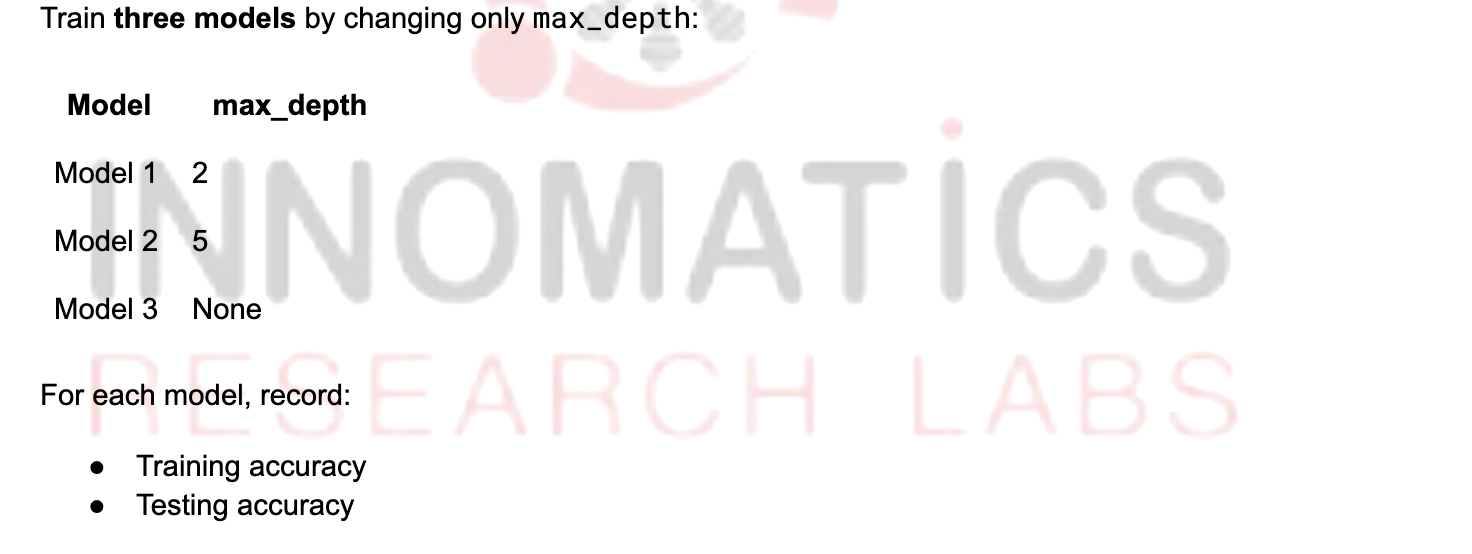

In [36]:
# List of depths to test [cite: 48]
depths = [2, 5, None]
results = []

print(f"{'Depth':<10} {'Train Acc':<15} {'Test Acc':<15}")
print("-" * 40)

for depth in depths:
    # Initialize model with specific depth
    temp_model = DecisionTreeClassifier(max_depth=depth, random_state=42)

    # Train
    temp_model.fit(X_train, y_train)

    # Record accuracies [cite: 49, 50, 51]
    train_acc = temp_model.score(X_train, y_train)
    test_acc = temp_model.score(X_test, y_test)

    results.append((depth, train_acc, test_acc))
    print(f"{str(depth):<10} {train_acc:.4f}          {test_acc:.4f}")

Depth      Train Acc       Test Acc       
----------------------------------------
2          0.7695          0.6780
5          0.9293          0.8439
None       1.0000          0.9854


### 1. What happens when the tree is very shallow?


When the tree is very shallow (Model 1, Depth 2), the model underfits.

The Training Accuracy (76.95%) and Testing Accuracy (67.80%) are both the lowest among the three models. A depth of 2 is too simple to capture the complex patterns and relationships in the medical data, leading to high bias and poor performance.

### 2. What happens when the tree is very deep?


When the tree is very deep (Model 3, Depth None), the model tends to overfit (or learn perfectly).

The Training Accuracy reached 100%, which means the tree grew until it memorized every single data point in the training set, including noise.

In this specific dataset, the Testing Accuracy was also extremely high (98.54%), which is unusual and suggests the dataset might have distinct separation or duplicates. However, theoretically, an unconstrained tree usually results in a model that does not generalize well to new, unseen data compared to a tuned model.

### 3. Which model performs best and why?


Model 3 (max_depth=None) performed the best in this specific experiment.

It achieved the highest Testing Accuracy (98.54%). It was able to utilize the full complexity of the features to distinguish between heart disease and no heart disease.

While Model 3 performed best here, in real-world scenarios, we often prefer a model like Model 2 (Depth 5). Model 2 offers a good balance (92.9% Train vs 84.4% Test), avoiding the extreme complexity of Model 3. A 100% training score (like in Model 3) is often a "warning sign" that the model might fail on completely new data in the future.

# 7. Part G: Tree Visualization


### 1. Visualize one Decision Tree (choose the best-performing one).


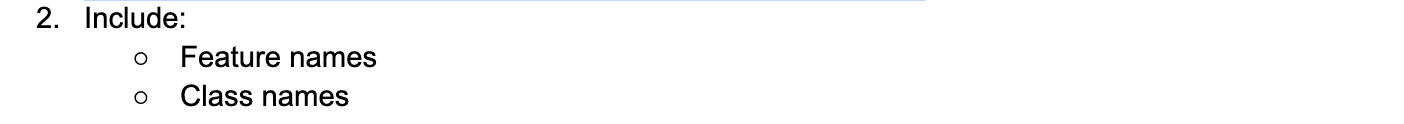

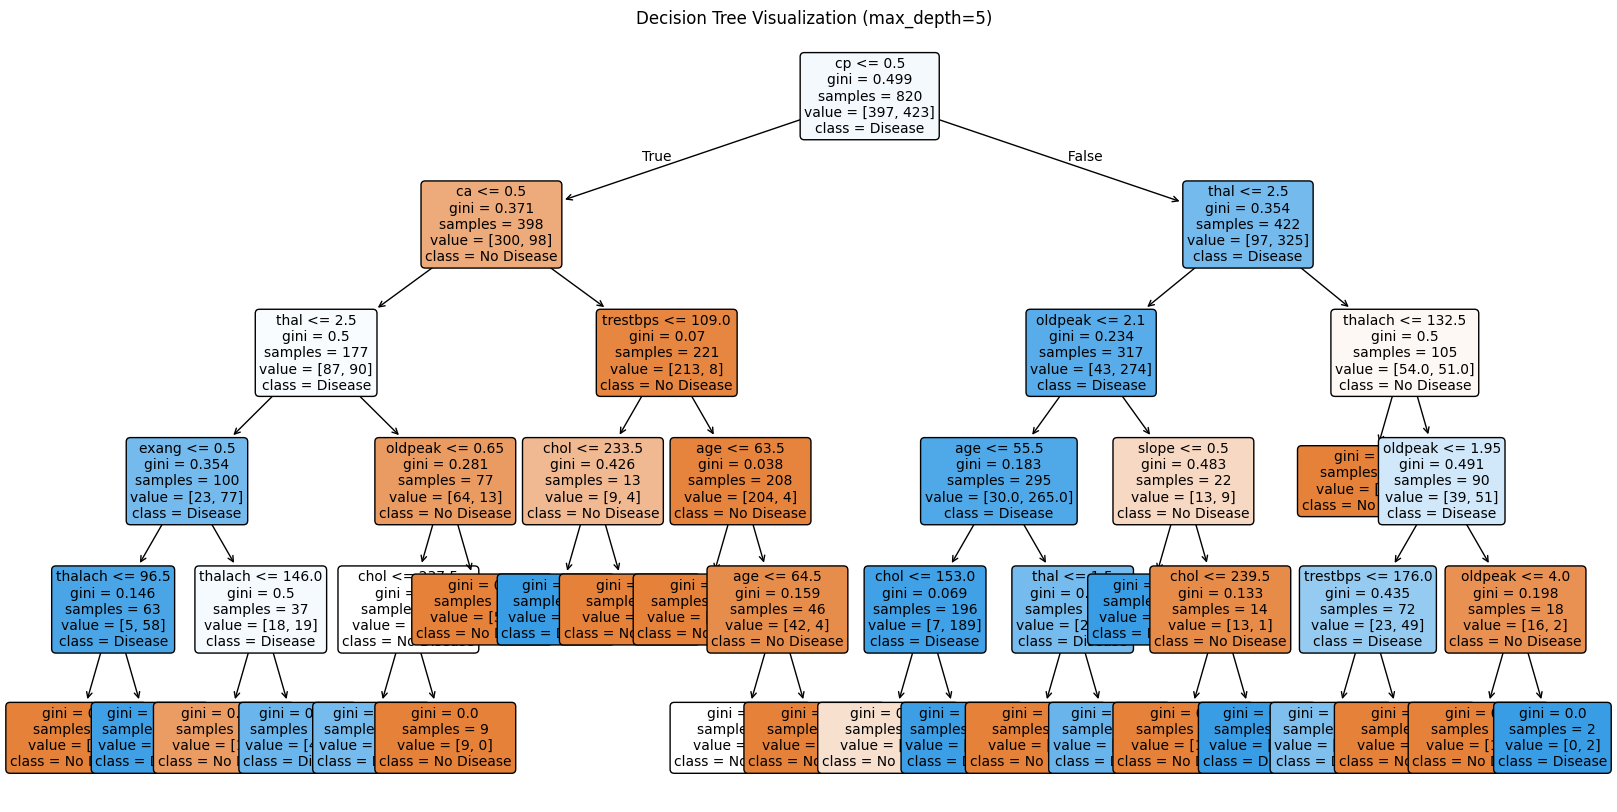

In [37]:
from sklearn.tree import plot_tree

# Retrain the best model (assuming Depth 5 was best from previous step)
best_model = DecisionTreeClassifier(max_depth=5, random_state=42)
best_model.fit(X_train, y_train)

# Visualize
plt.figure(figsize=(20, 10))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=['No Disease', 'Disease'], # Adjust based on your target values
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Visualization (max_depth=5)")
plt.show()

# 8. Part H: Reflection Questions


### 1. Why are Decision Trees suitable for medical datasets?


They mimic human clinical reasoning. Doctors often follow a flowchart logic (e.g., "If patient is over 50 AND smokes, check X"). Decision trees explicitly map out these rules, making them trustworthy and easy to validate against medical guidelines.

### 2. What makes Decision Trees easy to interpret?


Unlike "black box" models like Neural Networks, Decision Trees are "white box" models. You can visualize the entire tree (as done in Part G) and trace exactly why a specific prediction was made by following the path from the root to the leaf.

### 3. Why are Decision Trees commonly used in ensemble methods?


Decision Trees are "high variance" learners (unstable). If you change the data slightly, the tree structure changes drastically. Ensemble methods like Random Forest (Bagging) and Gradient Boosting take advantage of this by averaging many trees to reduce variance and improve accuracy significantly.

# 9. Finally Check with these below parameter


### 1. Compare criterion='gini' vs criterion='entropy'


In [38]:
model_gini = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
model_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

model_gini.fit(X_train, y_train)
model_entropy.fit(X_train, y_train)

print(f"Gini Accuracy: {model_gini.score(X_test, y_test):.4f}")
print(f"Entropy Accuracy: {model_entropy.score(X_test, y_test):.4f}")

Gini Accuracy: 0.8439
Entropy Accuracy: 0.8439


### 2. Try min_samples_leaf manually


In [39]:
# min_samples_leaf ensures a node is not split if it leaves very few samples in a child node
# This smooths the model.
model_leaf = DecisionTreeClassifier(min_samples_leaf=10, random_state=42)
model_leaf.fit(X_train, y_train)
print(f"Min Samples Leaf (10) Test Accuracy: {model_leaf.score(X_test, y_test):.4f}")

Min Samples Leaf (10) Test Accuracy: 0.8585


### 3. Write a short conclusion


In this assignment, we explored Decision Tree Classification on the Heart Disease dataset.

We learned that while Decision Trees are highly interpretable and intuitive, they are prone to overfitting when left unconstrained (max_depth=None).

By applying hyperparameter tuning (limiting depth or setting leaf constraints), we can create a model that generalizes better to unseen medical data.

The visualization confirmed that the model uses key health metrics (like Chest Pain or Thal) to make decisions, aligning with medical intuition.